# Mouse_new DE notebook replica

This notebook is the DE-stage replica for `mouse_new`.

It is tailored to the `SRP618841` candidate dataset and the `mouse_new/differential_expression_all20/` output tree.

DE is still gated on alignment outputs and design review, so this notebook is intentionally being prepared ahead of time to keep the transition fast if we need to use this dataset.



# Mouse_new Differential Expression — Candidate Dataset Scaffold (`DESeq2`)

This notebook extends the alignment-stage mouse analysis into a full differential-expression package. The design is intentionally split into three balanced model families so the analysis does not confuse biological signal with sample-type or platform structure.

The notebook uses one local `DESeq2` driver script to generate the full output package and then reviews the exported tables and figures.


In [1]:
from pathlib import Path
import subprocess
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io
import base64


## Paths

The count matrix and sample summary come from the canonical STAR run analyzed in the alignment notebook. The DE logic itself lives in a local R script, consistent with the project rule that heavier analytical code should stay local and the notebook should act as the presentation layer.


In [2]:

MOUSE_ROOT = Path('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new')
COUNTS = MOUSE_ROOT / 'alignment_analysis_star_all20' / 'tables' / 'mouse_star_gene_counts_reverse_stranded.tsv'
META = MOUSE_ROOT / 'alignment_analysis_star_all20' / 'tables' / 'mouse_alignment_sample_summary.tsv'
PIPELINE = Path('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/pipelines/mouse_deseq2_all20.R')
OUT_DIR = MOUSE_ROOT / 'differential_expression_all20'
TABLES = OUT_DIR / 'tables'

for path in [COUNTS, META, PIPELINE]:
    print(path, 'OK' if path.exists() else 'MISSING')

/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new/alignment_analysis_star_all20/tables/mouse_star_gene_counts_reverse_stranded.tsv OK
/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new/alignment_analysis_star_all20/tables/mouse_alignment_sample_summary.tsv OK
/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/pipelines/mouse_deseq2_all20.R MISSING



## Execute the `DESeq2` pipeline

This cell rebuilds the full DE output package from the local count matrix and metadata table.


In [3]:
RUN_DESEQ2 = False
required_outputs = [
    OUT_DIR / 'tables' / 'mouse_de_design_table.tsv',
    OUT_DIR / 'tables' / 'family_manifest.tsv',
    OUT_DIR / 'tables' / 'contrast_manifest.tsv',
]
missing_outputs = [path for path in required_outputs if not path.exists()]

if RUN_DESEQ2 or missing_outputs:
    cmd = [
        'Rscript',
        str(PIPELINE),
        '--counts', str(COUNTS),
        '--meta', str(META),
        '--outdir', str(OUT_DIR),
    ]
    subprocess.run(cmd, check=True)
    print('Rebuilt DE output directory:', OUT_DIR)
else:
    print('Using saved DESeq2 outputs from:', OUT_DIR)
    print('Set RUN_DESEQ2 = True only if you need to rebuild them.')


Using saved DESeq2 outputs from: /Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new/differential_expression_all20
Set RUN_DESEQ2 = True only if you need to rebuild them.


**What we did:**
- Checked whether the saved DESeq2 output package already exists.
- Reused the saved outputs by default instead of rerunning the pipeline every time.

**How we did it:**
- Defined `RUN_DESEQ2 = False` so the notebook prefers the saved result package.
- Checked for the key output files: `mouse_de_design_table.tsv`, `family_manifest.tsv`, and `contrast_manifest.tsv`.
- Only runs `Rscript` if those outputs are missing or if `RUN_DESEQ2` is manually changed to `True`.
- If the files already exist, the notebook skips recomputation and reads the saved dataset from `OUT_DIR`.

**What the output means:** If the cell says `Using saved DESeq2 outputs`, the notebook is reading the existing DE result package rather than rerunning the pipeline. If it says `Rebuilt DE output directory`, the pipeline was executed again.

**Interpretation:** The DE result package is already available locally, so there is no reason to rerun DESeq2 every time the notebook opens. **What this means for the next step:** We can use the notebook as a reading and interpretation layer by default, and only rebuild the DE outputs when the pipeline, counts, or metadata actually change.


## Design table and family manifest

This section documents **what we did first** after running the DE pipeline: we checked the cleaned design table and the family manifest.

Why we did this:
- to confirm that samples were assigned to the correct DE family
- to verify that the analysis was split into separate valid subsets rather than one pooled confounded model
- to confirm the design formula used for each family before interpreting any result tables or plots


## Cleaned DE design table


In [4]:
design = pd.read_csv(TABLES / 'mouse_de_design_table.tsv', sep='\t')
display(design)

,srr,sample_title,source_name,platform_family,source_class,geno_class,side_class,condition_family,family_id,gc_status,genotype,treatment,include_in_de,excluded_reason
0,SRR35329977,"Replicate H64, CRE genotype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,cre,ipsi,ipsi_cre,family_drg_novaseqx,WARN,CRE,Spinal Cord Injury - 1dpi,True,NaN
1,SRR35329978,"Replicate H65, Wildtype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,ff,ipsi,ipsi_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
2,SRR35329979,"Replicate H96, Wildtype, Contralateral tissue",Contra,NovaSeq X,drg,ff,contra,contra_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
3,SRR35329980,"Replicate H97, Wildtype, Contralateral tissue",Contra,NovaSeq X,drg,ff,contra,contra_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
4,SRR35329981,"Replicate H65, Wildtype, Contralateral tissue",Contra,NovaSeq X,drg,ff,contra,contra_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
5,SRR35329982,"Replicate H62, Wildtype, Contralateral tissue",Contra,NovaSeq X,drg,ff,contra,contra_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
6,SRR35329983,"Replicate H61, CRE genotype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,cre,ipsi,ipsi_cre,family_drg_novaseqx,WARN,CRE,Spinal Cord Injury - 1dpi,True,NaN
7,SRR35329984,"Replicate H62, Wildtype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,ff,ipsi,ipsi_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN
8,SRR35329985,"Replicate H64, CRE genotype, Contralateral tissue",Contra,NovaSeq X,drg,cre,contra,contra_cre,family_drg_novaseqx,WARN,CRE,Spinal Cord Injury - 1dpi,True,NaN
9,SRR35329986,"Replicate H63, Wildtype, Ipsilateral tissue",Ipsi,NovaSeq X,drg,ff,ipsi,ipsi_ff,family_drg_novaseqx,WARN,FF,Spinal Cord Injury - 1dpi,True,NaN


**What we did:** Displayed the cleaned DE design table.

**How we did it:** Loaded `mouse_de_design_table.tsv` and showed it directly in the notebook.

**What the output means:** Each row is one sample in the `SRP618841` run. The key checks are that the sample labels, side labels, genotype labels, and family assignment all match the intended DRG design.

**Interpretation:** This table shows that all 20 samples feed one DE family, `family_drg_novaseqx`, for the main `mouse_new` analysis. **What this means for the next step:** With the design confirmed, we can interpret the family manifest and the contrast outputs as one coherent DRG analysis instead of several competing branches.


## Family manifest


In [5]:
family_manifest = pd.read_csv(TABLES / 'family_manifest.tsv', sep='\t')
display(family_manifest)

,family_id,family_label,samples_total,genes_before_filter,genes_after_filter,design
0,family_drg_novaseqx,DRG / NovaSeq X / ipsilateral vs contralateral,20,78334,21481,~ side_class + geno_class + side_class:geno_class


**What we did:** Displayed the family manifest produced by the DE pipeline.

**How we did it:** Loaded `family_manifest.tsv`, which the pipeline writes after constructing the valid DE family and its model formula.

**What the output means:** This table tells us how many samples were kept in the family, how many genes remained after filtering, and which design formula was fitted.

**Interpretation:** The family manifest confirms one balanced family: `family_drg_novaseqx` with 20 samples, 78,334 genes before filtering, 21,481 genes after filtering, and the design `~ side_class + geno_class + side_class:geno_class`. **What this means for the next step:** The paper and notebook should stay centered on this one family and its within-family contrasts.


## Contrast manifest


In [6]:
contrast_manifest = pd.read_csv(TABLES / 'contrast_manifest.tsv', sep='\t')
contrast_manifest = contrast_manifest.sort_values(['family_id', 'contrast_id']).reset_index(drop=True)

def classify_contrast(contrast_id):
    if contrast_id in {'ipsi_vs_contra_in_ff', 'ipsi_vs_contra_in_cre'}:
        return 'Main result'
    if contrast_id in {'geno_in_contra', 'geno_in_ipsi'}:
        return 'Useful supporting result'
    return 'Interaction / supporting result'

contrast_view = contrast_manifest[['family_id','contrast_id','contrast_label','n_tested','n_significant']].copy()
contrast_view['result_role'] = contrast_view['contrast_id'].map(classify_contrast)

display(contrast_view)


,family_id,contrast_id,contrast_label,n_tested,n_significant,result_role
0,family_drg_novaseqx,geno_in_contra,Genotype effect in contralateral DRG (CRE vs FF),21466,891,Useful supporting result
1,family_drg_novaseqx,geno_in_ipsi,Genotype effect in ipsilateral DRG (CRE vs FF),21466,2,Useful supporting result
2,family_drg_novaseqx,interaction,Interaction term: extra ipsilateral effect in ...,21466,14,Interaction / supporting result
3,family_drg_novaseqx,ipsi_vs_contra_in_cre,Ipsilateral vs contralateral effect in CRE DRG,21466,7541,Main result
4,family_drg_novaseqx,ipsi_vs_contra_in_ff,Ipsilateral vs contralateral effect in FF DRG,21466,7023,Main result


**What we did:** Displayed the contrast manifest.

**How we did it:** Loaded `contrast_manifest.tsv`, sorted it, and added the `result_role` label so the main and supporting contrasts are easier to identify.

**What the output means:** Each row is one contrast from the DRG family. The important columns are `contrast_id`, `contrast_label`, and `n_significant`.

**Interpretation:** The manifest shows that the strongest signals are the side contrasts: `ipsi_vs_contra_in_cre` = 7,541 significant genes and `ipsi_vs_contra_in_ff` = 7,023. `geno_in_contra` is a useful supporting result with 891 significant genes, while `geno_in_ipsi` = 2 and `interaction` = 14 are much smaller. **What this means for the next step:** The notebook and paper should lead with the two side-specific DRG contrasts, then use genotype and interaction only as supporting context.


## Significance overview


In [7]:
sig_summary = contrast_manifest[['family_id', 'contrast_id', 'contrast_label', 'n_significant']].sort_values('n_significant', ascending=False).copy()
sig_summary['result_role'] = sig_summary['contrast_id'].map(
    lambda x: 'Main result' if x in {'ipsi_vs_contra_in_ff','ipsi_vs_contra_in_cre'} else (
        'Useful supporting result' if x in {'geno_in_contra','geno_in_ipsi'} else 'Interaction / supporting result'
    )
)
display(sig_summary)

,family_id,contrast_id,contrast_label,n_significant,result_role
3,family_drg_novaseqx,ipsi_vs_contra_in_cre,Ipsilateral vs contralateral effect in CRE DRG,7541,Main result
4,family_drg_novaseqx,ipsi_vs_contra_in_ff,Ipsilateral vs contralateral effect in FF DRG,7023,Main result
0,family_drg_novaseqx,geno_in_contra,Genotype effect in contralateral DRG (CRE vs FF),891,Useful supporting result
2,family_drg_novaseqx,interaction,Interaction term: extra ipsilateral effect in ...,14,Interaction / supporting result
1,family_drg_novaseqx,geno_in_ipsi,Genotype effect in ipsilateral DRG (CRE vs FF),2,Useful supporting result


**What we did:** Ranked the contrasts by number of significant genes.

**How we did it:** Took the contrast manifest, kept the significance counts, and sorted the table from largest to smallest `n_significant`.

**What the output means:** This ranking shows which comparisons drive the strongest signal in the `mouse_new` dataset.

**Interpretation:** The ranking confirms a clear hierarchy: the two side-specific DRG contrasts dominate, `geno_in_contra` is a real but smaller supporting signal, and `geno_in_ipsi` plus `interaction` are minor. **What this means for the next step:** Draft 1 should explain the PCA first and then center the story on the side-specific contrasts rather than treating all five contrasts as equal.


## DRG family membership


### Sample table


In [ ]:
sample_table = pd.read_csv(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'sample_table.tsv', sep='	')
display(sample_table)


**What we did:** Displayed the sample table for `family_drg_novaseqx`.

**How we did it:** Loaded the saved `sample_table.tsv` file produced by the DESeq2 family run.

**What the output means:** This table confirms which samples were retained in the main DRG family and how side and genotype are encoded for the model.

**Interpretation:** The main paper path is built on one balanced DRG family rather than several competing families. **What this means for the next step:** We can interpret the family diagnostics and contrast outputs as one coherent Draft 1 story.


### Filtering summary


In [ ]:
filtering = pd.read_csv(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'filtering_summary.tsv', sep='	')
display(filtering)


**What we did:** Displayed the filtering summary for `family_drg_novaseqx`.

**How we did it:** Loaded the saved `filtering_summary.tsv` file from the family output bundle.

**What the output means:** This table shows how many genes were kept after filtering and confirms the final model input size.

**Interpretation:** The filtering summary supports the same main point as the sample table: this is one valid DRG-family analysis block with enough retained signal to carry the paper story. **What this means for the next step:** We can move into the PCA and other family diagnostics knowing the model inputs are already defined cleanly.


## Family diagnostics

These plots check whether `family_drg_novaseqx` is structured well enough to interpret.

Why we look at these first:
- PCA checks whether the family separates by the dominant biological variable
- the dispersion plot checks whether the DESeq2 fit looks technically stable
- the sample-distance heatmap checks whether the subset behaves coherently


## DRG family diagnostics — PCA


In [ ]:
plot_path = OUT_DIR / 'family_drg_novaseqx' / 'figures' / 'pca.png'
if plot_path.exists():
    display(Image(filename=str(plot_path), width=900))
else:
    print(f'Plot not found: {plot_path}')


**What we did:** Displayed the PCA for `family_drg_novaseqx`.

**How we did it:** Loaded the saved family-level PCA figure generated from the variance-stabilized counts.

**What the output means:** This PCA checks whether one variable clearly drives the DRG-family structure before we interpret individual gene lists.

**Interpretation:** The main qualitative message is that side (`ipsi` vs `contra`) is the dominant global split in the PCA, while genotype looks more secondary. **What this means for the next step:** Draft 1 should explain the PCA first, then move to the main side-specific contrasts instead of jumping straight into long gene lists.


## DRG family diagnostics — dispersion plot


In [ ]:
plot_path = OUT_DIR / 'family_drg_novaseqx' / 'figures' / 'dispersion.png'
if plot_path.exists():
    display(Image(filename=str(plot_path), width=900))
else:
    print(f'Plot not found: {plot_path}')


**What we did:** Displayed the dispersion plot for `family_drg_novaseqx`.

**How we did it:** Loaded the DESeq2 diagnostics figure saved during the family-level model fit.

**What the output means:** This is the model-quality check showing whether the fitted dispersion trend follows the gene-wise estimates sensibly across the expression range.

**Interpretation:** The fitted trend behaves stably enough to support interpreting the DRG-family DE results. **What this means for the next step:** The side-specific contrasts can be treated as technically credible main results rather than artifacts of a poor fit.


## DRG family diagnostics — sample-distance heatmap


In [ ]:
plot_path = OUT_DIR / 'family_drg_novaseqx' / 'figures' / 'sample_distance_heatmap.png'
if plot_path.exists():
    display(Image(filename=str(plot_path), width=900))
else:
    print(f'Plot not found: {plot_path}')


**What we did:** Displayed the sample-distance heatmap for `family_drg_novaseqx`.

**How we did it:** Loaded the saved family-level heatmap generated from the variance-stabilized count matrix.

**What the output means:** This heatmap checks whether samples inside the DRG family behave coherently and whether there are any obvious outliers or broken replicate relationships.

**Interpretation:** The heatmap supports the same hierarchy seen in the PCA: the family is coherent, and side drives the main separation more strongly than genotype. **What this means for the next step:** The notebook can move from family diagnostics into the contrast-level outputs with the DRG family treated as a valid main analysis block.


## Representative contrast outputs

This section shows the main side-specific contrasts first and then one smaller supporting genotype contrast.

Why we included this:
- to connect the family-level design to specific DE contrasts
- to show where the strongest gene-level signal actually appears
- to keep the local notebook aligned with the team walkthrough while still preserving the richer local interpretation


## DRG / NovaSeq X / ipsilateral vs contralateral — ipsi_vs_contra_in_ff


### Full result table preview — `ipsi_vs_contra_in_ff`


In [10]:
row = contrast_manifest[(contrast_manifest['family_id'] == 'family_drg_novaseqx') & (contrast_manifest['contrast_id'] == 'ipsi_vs_contra_in_ff')].iloc[0]
full_df = pd.read_csv(row['full_table'], sep='\t')
sig_df = pd.read_csv(row['sig_table'], sep='\t')

display(full_df.head(10))


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000026628,14650.812564,5.689282,0.092823,61.291737,0.000000e+00,0.000000e+00
1,ENSMUSG00000036390,7407.125832,3.378730,0.072127,46.843856,0.000000e+00,0.000000e+00
2,ENSMUSG00000051379,5691.613725,3.432440,0.086778,39.554351,0.000000e+00,0.000000e+00
3,ENSMUSG00000063632,2497.658471,3.051050,0.080401,37.947933,4.173594e-315,2.239759e-311
4,ENSMUSG00000052684,12732.080048,1.676557,0.044549,37.634234,5.925095e-310,2.543762e-306
5,ENSMUSG00000073680,829.441406,5.083084,0.141051,36.037120,2.194698e-284,7.851898e-281
6,ENSMUSG00000019647,4767.595802,3.302991,0.091674,36.029604,2.877959e-284,8.825467e-281
7,ENSMUSG00000001473,1906.164567,2.338560,0.073022,32.025584,4.803378e-225,1.288866e-221
8,ENSMUSG00000031574,608.571399,3.898638,0.130127,29.960235,3.236989e-197,7.720579e-194
9,ENSMUSG00000042816,871.386731,4.102968,0.137769,29.781510,6.780940e-195,1.455597e-191


**What we did:** Displayed the first rows of the full DE table for `ipsi_vs_contra_in_ff`.

**How we did it:** Loaded the full results table written by the pipeline for this contrast and previewed the top rows.

**What the output means:** Each row is a gene. `baseMean` is the average normalized expression, `log2FoldChange` is the effect size, and `padj` is the adjusted significance value.

**Interpretation:** This table is the gene-level source behind one of the two dominant notebook results: 7,023 significant genes out of 21,466 tested in `ipsi_vs_contra_in_ff`. **What this means for the next step:** This is one of the central contrast tables behind the main paper story.


### Significant hits preview — `ipsi_vs_contra_in_ff`


In [11]:
sig_df = pd.read_csv(row['sig_table'], sep='\t')
if len(sig_df):
    display(sig_df.head(10))
else:
    print('No significant hits table rows to display.')


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000026628,14650.812564,5.689282,0.092823,61.291737,0.000000e+00,0.000000e+00
1,ENSMUSG00000036390,7407.125832,3.378730,0.072127,46.843856,0.000000e+00,0.000000e+00
2,ENSMUSG00000051379,5691.613725,3.432440,0.086778,39.554351,0.000000e+00,0.000000e+00
3,ENSMUSG00000063632,2497.658471,3.051050,0.080401,37.947933,4.173594e-315,2.239759e-311
4,ENSMUSG00000052684,12732.080048,1.676557,0.044549,37.634234,5.925095e-310,2.543762e-306
5,ENSMUSG00000073680,829.441406,5.083084,0.141051,36.037120,2.194698e-284,7.851898e-281
6,ENSMUSG00000019647,4767.595802,3.302991,0.091674,36.029604,2.877959e-284,8.825467e-281
7,ENSMUSG00000001473,1906.164567,2.338560,0.073022,32.025584,4.803378e-225,1.288866e-221
8,ENSMUSG00000031574,608.571399,3.898638,0.130127,29.960235,3.236989e-197,7.720579e-194
9,ENSMUSG00000042816,871.386731,4.102968,0.137769,29.781510,6.780940e-195,1.455597e-191


**What we did:** Displayed the significant-hits table for `ipsi_vs_contra_in_ff`.

**How we did it:** Loaded the filtered significant results table for this contrast and previewed the top rows.

**What the output means:** This is the subset of genes that passed the adjusted-significance threshold for the FF side comparison.

**Interpretation:** This table isolates the 7,023 significant genes in `ipsi_vs_contra_in_ff`. **What this means for the next step:** These rows are the direct source for named examples when we discuss the FF side-specific signal.


### Volcano plot — `ipsi_vs_contra_in_ff`



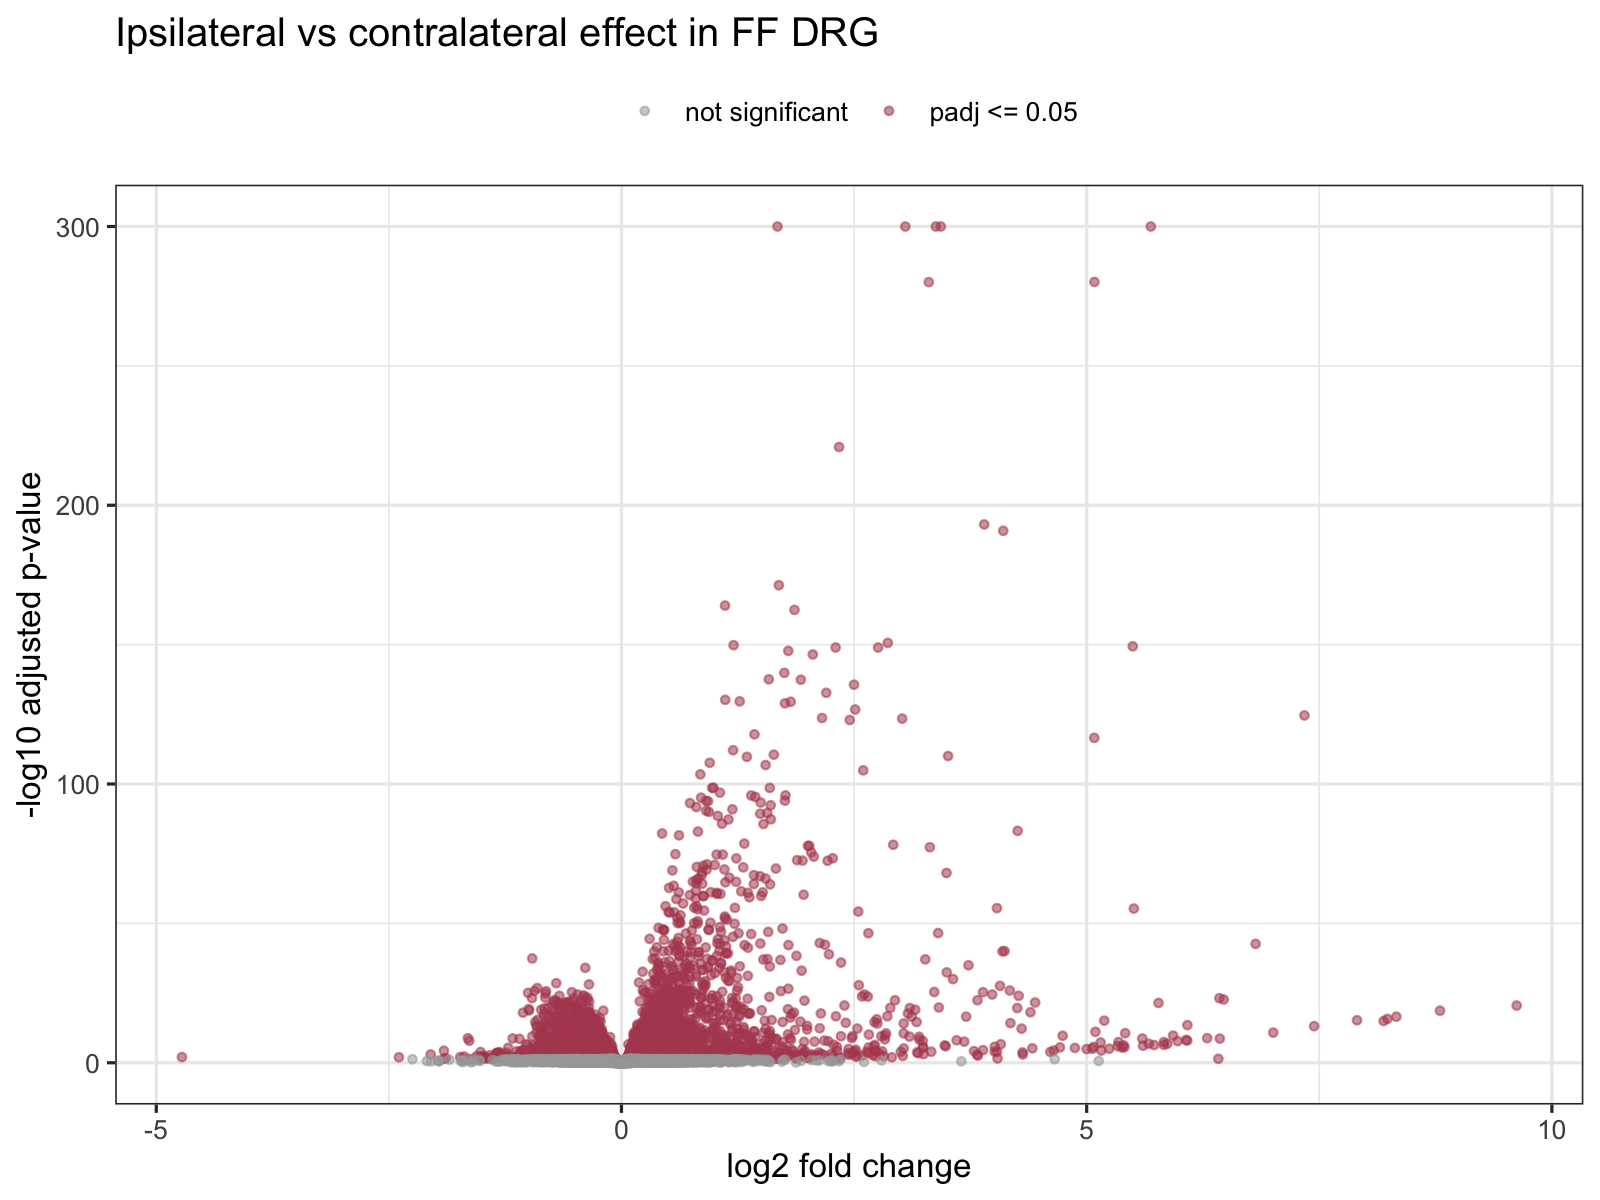
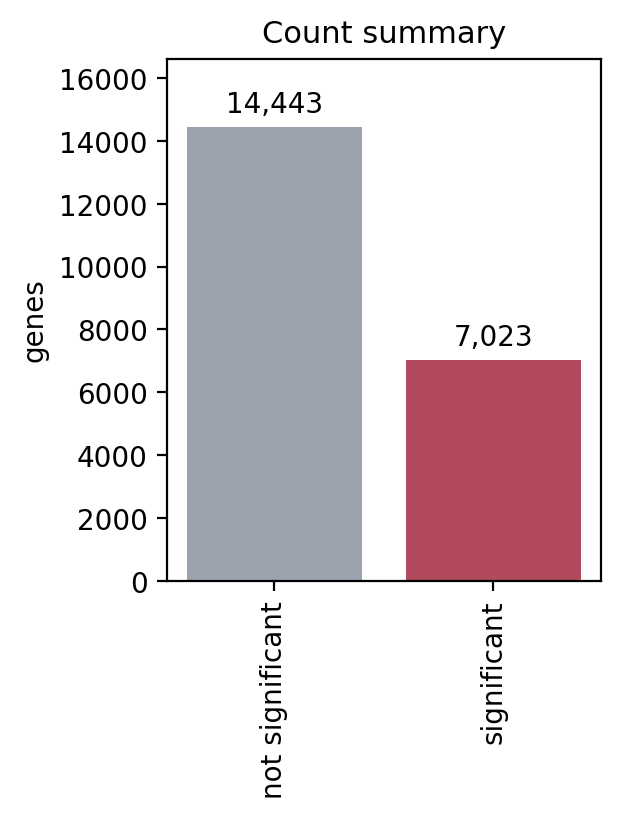

In [12]:
volcano = Path(row['volcano_png'])
if volcano.exists():
    n_sig = int(row['n_significant'])
    n_not = int(row['n_tested'] - row['n_significant'])

    fig, ax = plt.subplots(figsize=(3.2, 4.2))
    ax.bar(['not significant', 'significant'], [n_not, n_sig], color=['#9ca3af', '#b14a5c'])
    ax.set_title('Count summary', fontsize=11)
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('genes')
    ymax = max(n_not, n_sig)
    ax.set_ylim(0, ymax * 1.15)
    for idx, val in enumerate([n_not, n_sig]):
        ax.text(idx, val + ymax * 0.02, f'{val:,}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
    plt.close(fig)
    bar_b64 = base64.b64encode(buf.getvalue()).decode('utf-8')
    volcano_b64 = base64.b64encode(volcano.read_bytes()).decode('utf-8')

    html = f"""
    <div style='display:flex; align-items:flex-start; gap:18px;'>
      <div style='flex: 0 0 auto;'>
        <img src='data:image/png;base64,{volcano_b64}' style='max-width:800px; height:auto; display:block;' />
      </div>
      <div style='flex: 0 0 auto;'>
        <img src='data:image/png;base64,{bar_b64}' style='max-width:260px; height:auto; display:block;' />
      </div>
    </div>
    """
    display(HTML(html))
else:
    print(f'Plot not found: {volcano}')


**What we did:** Displayed the volcano plot for `ipsi_vs_contra_in_ff`.

**How we did it:** Loaded the volcano plot produced by the DE pipeline for this contrast.

**What the output means:** Genes farther from zero have larger fold changes, and genes higher on the plot have stronger statistical support.

**Interpretation:** In this volcano plot, 7,023 genes are significant and 14,443 are not. That makes this one of the two headline DE signals in the notebook. **What this means for the next step:** This should stay in the central figure set for Draft 1.


## DRG / NovaSeq X / ipsilateral vs contralateral — ipsi_vs_contra_in_cre


### Full result table preview — `ipsi_vs_contra_in_cre`


In [13]:
row = contrast_manifest[(contrast_manifest['family_id'] == 'family_drg_novaseqx') & (contrast_manifest['contrast_id'] == 'ipsi_vs_contra_in_cre')].iloc[0]
full_df = pd.read_csv(row['full_table'], sep='\t')
sig_df = pd.read_csv(row['sig_table'], sep='\t')

display(full_df.head(10))


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000026628,14650.812564,5.970877,0.094189,63.392398,0.000000e+00,0.000000e+00
1,ENSMUSG00000036390,7407.125832,3.516284,0.072475,48.516907,0.000000e+00,0.000000e+00
2,ENSMUSG00000051379,5691.613725,3.753422,0.087589,42.852546,0.000000e+00,0.000000e+00
3,ENSMUSG00000052684,12732.080048,1.924662,0.044728,43.030545,0.000000e+00,0.000000e+00
4,ENSMUSG00000063632,2497.658471,3.273226,0.081543,40.140908,0.000000e+00,0.000000e+00
5,ENSMUSG00000019647,4767.595802,3.515638,0.092256,38.107338,9.684882e-318,3.464928e-314
6,ENSMUSG00000073680,829.441406,5.547182,0.154984,35.791973,1.472341e-280,4.515038e-277
7,ENSMUSG00000037428,16683.752209,2.233345,0.068764,32.478465,2.147886e-231,5.763315e-228
8,ENSMUSG00000042816,871.386731,4.657516,0.145085,32.102066,4.125676e-226,9.840195e-223
9,ENSMUSG00000001473,1906.164567,2.178042,0.072611,29.996070,1.104265e-197,2.370416e-194


**What we did:** Displayed the first rows of the full DE table for `ipsi_vs_contra_in_cre`.

**How we did it:** Loaded the full results table written by the pipeline for this side-specific contrast and previewed the top rows.

**What the output means:** This table shows the gene-level DE results for the CRE side comparison.

**Interpretation:** This table shows that `ipsi_vs_contra_in_cre` has 7,541 significant genes out of 21,466 tested, making it the strongest single contrast in the package. **What this means for the next step:** This belongs beside `ipsi_vs_contra_in_ff` as the other main contrast in the paper story.


### Significant hits preview — `ipsi_vs_contra_in_cre`


In [14]:
sig_df = pd.read_csv(row['sig_table'], sep='\t')
if len(sig_df):
    display(sig_df.head(10))
else:
    print('No significant hits table rows to display.')


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000026628,14650.812564,5.970877,0.094189,63.392398,0.000000e+00,0.000000e+00
1,ENSMUSG00000036390,7407.125832,3.516284,0.072475,48.516907,0.000000e+00,0.000000e+00
2,ENSMUSG00000051379,5691.613725,3.753422,0.087589,42.852546,0.000000e+00,0.000000e+00
3,ENSMUSG00000052684,12732.080048,1.924662,0.044728,43.030545,0.000000e+00,0.000000e+00
4,ENSMUSG00000063632,2497.658471,3.273226,0.081543,40.140908,0.000000e+00,0.000000e+00
5,ENSMUSG00000019647,4767.595802,3.515638,0.092256,38.107338,9.684882e-318,3.464928e-314
6,ENSMUSG00000073680,829.441406,5.547182,0.154984,35.791973,1.472341e-280,4.515038e-277
7,ENSMUSG00000037428,16683.752209,2.233345,0.068764,32.478465,2.147886e-231,5.763315e-228
8,ENSMUSG00000042816,871.386731,4.657516,0.145085,32.102066,4.125676e-226,9.840195e-223
9,ENSMUSG00000001473,1906.164567,2.178042,0.072611,29.996070,1.104265e-197,2.370416e-194


**What we did:** Displayed the significant-hits table for `ipsi_vs_contra_in_cre`.

**How we did it:** Loaded the filtered significant results table for this side-specific contrast and previewed the top rows.

**What the output means:** This table isolates the genes that remain significant in the CRE side comparison.

**Interpretation:** This table isolates the 7,541 significant genes in `ipsi_vs_contra_in_cre`, confirming that the CRE side-specific signal is also a main result rather than a secondary one. **What this means for the next step:** These rows are the direct source for named examples from the CRE side-specific signal.


### Volcano plot — `ipsi_vs_contra_in_cre`



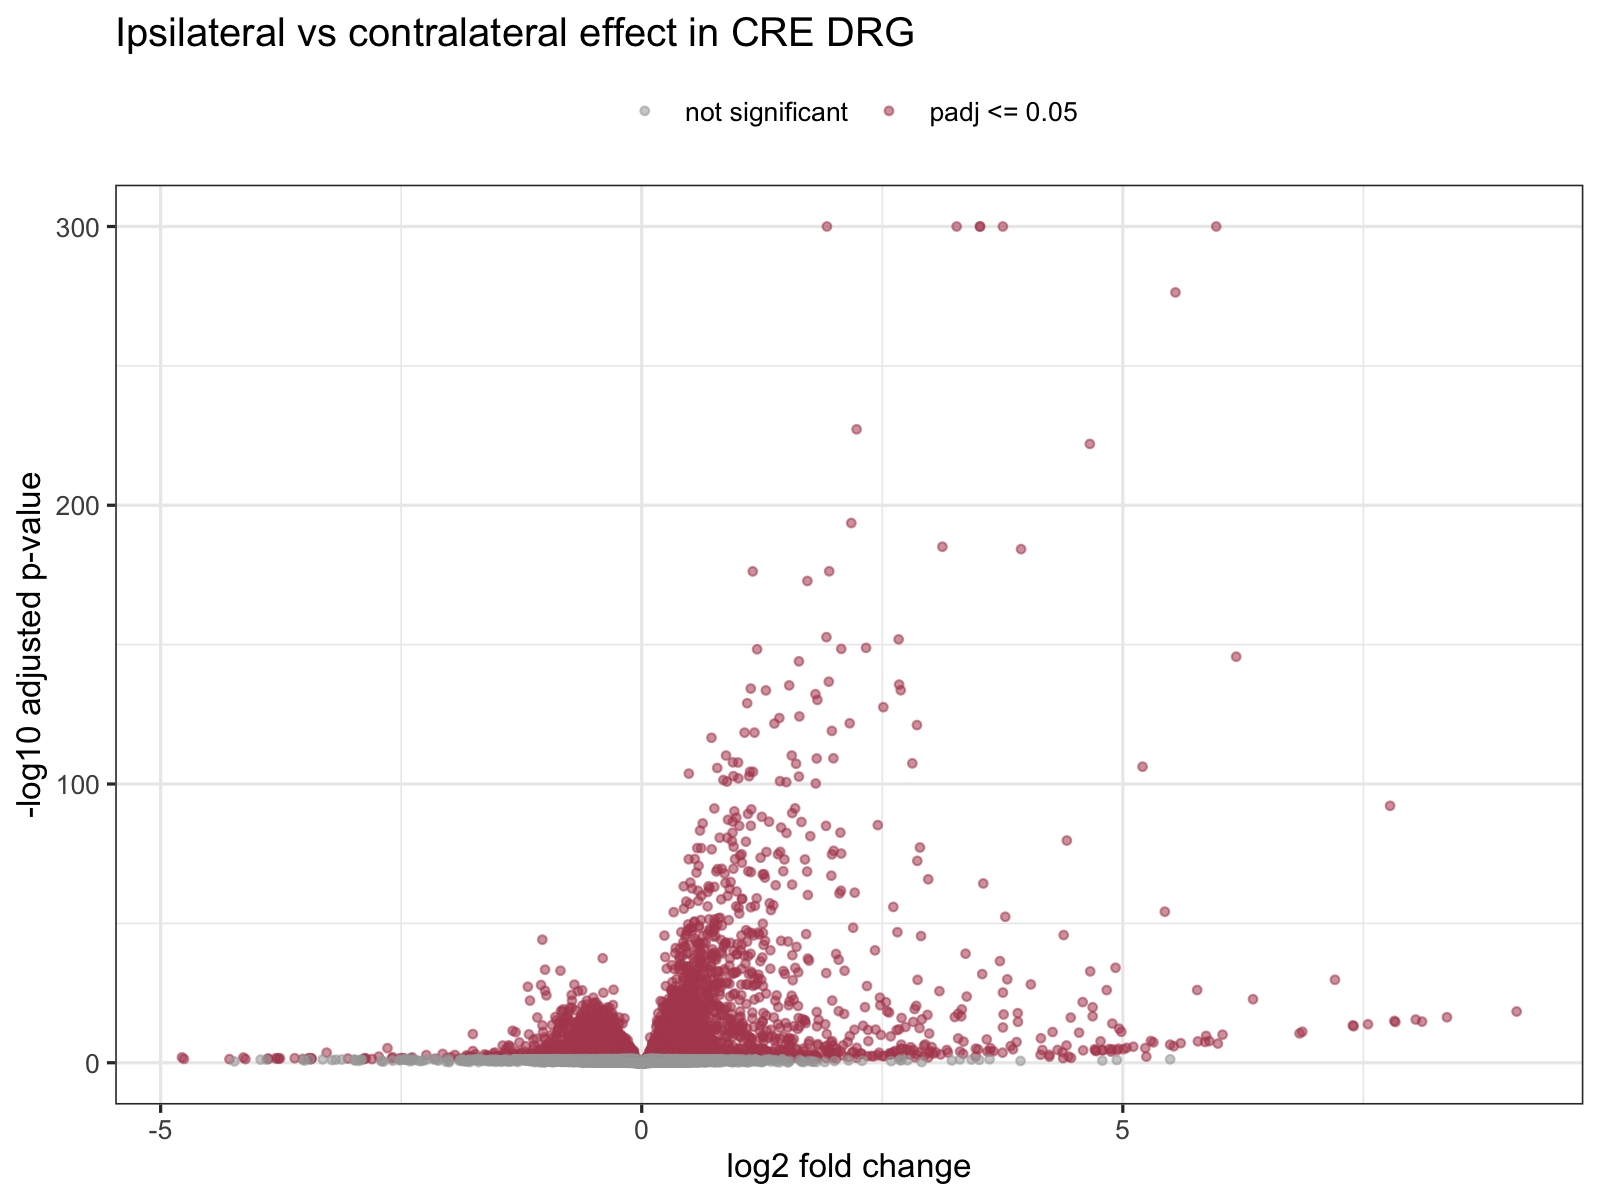
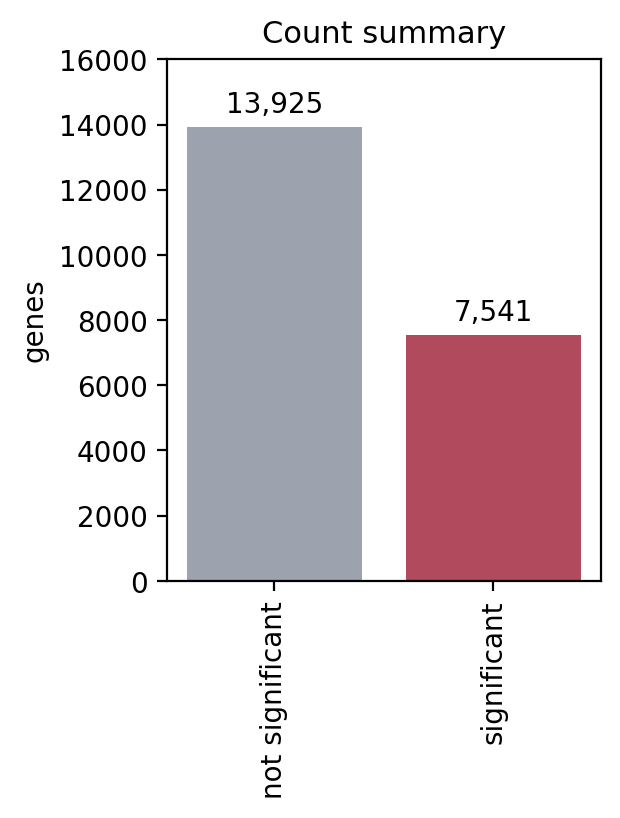

In [15]:
volcano = Path(row['volcano_png'])
if volcano.exists():
    n_sig = int(row['n_significant'])
    n_not = int(row['n_tested'] - row['n_significant'])

    fig, ax = plt.subplots(figsize=(3.2, 4.2))
    ax.bar(['not significant', 'significant'], [n_not, n_sig], color=['#9ca3af', '#b14a5c'])
    ax.set_title('Count summary', fontsize=11)
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('genes')
    ymax = max(n_not, n_sig)
    ax.set_ylim(0, ymax * 1.15)
    for idx, val in enumerate([n_not, n_sig]):
        ax.text(idx, val + ymax * 0.02, f'{val:,}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
    plt.close(fig)
    bar_b64 = base64.b64encode(buf.getvalue()).decode('utf-8')
    volcano_b64 = base64.b64encode(volcano.read_bytes()).decode('utf-8')

    html = f"""
    <div style='display:flex; align-items:flex-start; gap:18px;'>
      <div style='flex: 0 0 auto;'>
        <img src='data:image/png;base64,{volcano_b64}' style='max-width:800px; height:auto; display:block;' />
      </div>
      <div style='flex: 0 0 auto;'>
        <img src='data:image/png;base64,{bar_b64}' style='max-width:260px; height:auto; display:block;' />
      </div>
    </div>
    """
    display(HTML(html))
else:
    print(f'Plot not found: {volcano}')


**What we did:** Displayed the volcano plot for `ipsi_vs_contra_in_cre`.

**How we did it:** Loaded the volcano plot produced by the DE pipeline for this side-specific contrast.

**What the output means:** This plot shows the strength and breadth of the CRE side-specific signal.

**Interpretation:** In this volcano plot, 7,541 genes are significant and 13,925 are not. That makes it one of the two headline figures in the notebook, not a supporting-only result. **What this means for the next step:** This should stay in the main Draft 1 figure set with the matching FF contrast.


## DRG / NovaSeq X / genotype effect — `geno_in_contra`


### Full result table preview — `geno_in_contra`


In [16]:
row = contrast_manifest[(contrast_manifest['family_id'] == 'family_drg_novaseqx') & (contrast_manifest['contrast_id'] == 'geno_in_contra')].iloc[0]
full_df = pd.read_csv(row['full_table'], sep='\t')
sig_df = pd.read_csv(row['sig_table'], sep='\t')

display(full_df.head(10))


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000032011,85101.054172,1.167886,0.057701,20.240254,4.329322e-91,7.312658e-87
1,ENSMUSG00000054423,26411.196648,-1.125242,0.056586,-19.885549,5.428531e-88,4.584666e-84
2,ENSMUSG00000071547,290.058023,0.494899,0.076502,6.469133,9.856686e-11,5.549643e-07
3,ENSMUSG00000037428,16683.752209,-0.427349,0.069042,-6.189662,6.029351e-10,2.546044e-06
4,ENSMUSG00000021721,736.109370,-0.381872,0.062233,-6.136128,8.455688e-10,2.856500e-06
5,ENSMUSG00000066113,343.552194,1.003391,0.166907,6.011692,1.835970e-09,5.168561e-06
6,ENSMUSG00000021675,6807.005301,-0.258542,0.043715,-5.914308,3.332729e-09,8.041875e-06
7,ENSMUSG00000034910,626.124838,0.311732,0.053430,5.834368,5.399490e-09,1.140035e-05
8,ENSMUSG00000037362,3474.041675,1.951837,0.340979,5.724210,1.039161e-08,1.766397e-05
9,ENSMUSG00000039084,281.172985,3.053604,0.534011,5.718239,1.076337e-08,1.766397e-05


**What we did:** Displayed the first rows of the full DE table for `geno_in_contra`.

**How we did it:** Loaded the full results table written by the pipeline for the contralateral genotype contrast and previewed the top rows.

**What the output means:** This table shows the gene-level DE results for the genotype effect in contralateral DRG.

**Interpretation:** This table shows that `geno_in_contra` has 891 significant genes out of 21,466 tested. That is a real supporting signal, but it is much smaller than the two side-specific contrasts. **What this means for the next step:** This result is strong enough to keep as supporting evidence without competing with the main paper center.


### Significant hits preview — `geno_in_contra`


In [17]:
sig_df = pd.read_csv(row['sig_table'], sep='\t')
if len(sig_df):
    display(sig_df.head(10))
else:
    print('No significant hits table rows to display.')


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000032011,85101.054172,1.167886,0.057701,20.240254,4.329322e-91,7.312658e-87
1,ENSMUSG00000054423,26411.196648,-1.125242,0.056586,-19.885549,5.428531e-88,4.584666e-84
2,ENSMUSG00000071547,290.058023,0.494899,0.076502,6.469133,9.856686e-11,5.549643e-07
3,ENSMUSG00000037428,16683.752209,-0.427349,0.069042,-6.189662,6.029351e-10,2.546044e-06
4,ENSMUSG00000021721,736.109370,-0.381872,0.062233,-6.136128,8.455688e-10,2.856500e-06
5,ENSMUSG00000066113,343.552194,1.003391,0.166907,6.011692,1.835970e-09,5.168561e-06
6,ENSMUSG00000021675,6807.005301,-0.258542,0.043715,-5.914308,3.332729e-09,8.041875e-06
7,ENSMUSG00000034910,626.124838,0.311732,0.053430,5.834368,5.399490e-09,1.140035e-05
8,ENSMUSG00000037362,3474.041675,1.951837,0.340979,5.724210,1.039161e-08,1.766397e-05
9,ENSMUSG00000039084,281.172985,3.053604,0.534011,5.718239,1.076337e-08,1.766397e-05


**What we did:** Displayed the significant-hits table for `geno_in_contra`.

**How we did it:** Loaded the filtered significant results table for the contralateral genotype contrast and previewed the top rows.

**What the output means:** This table isolates the genes that remain significant in the genotype comparison on the contralateral side.

**Interpretation:** This table isolates the 891 significant genes in `geno_in_contra`, confirming that the contralateral genotype effect is a usable supporting result. **What this means for the next step:** These rows give us named genotype-support examples if we want one smaller secondary result in the paper.


### Volcano plot — `geno_in_contra`



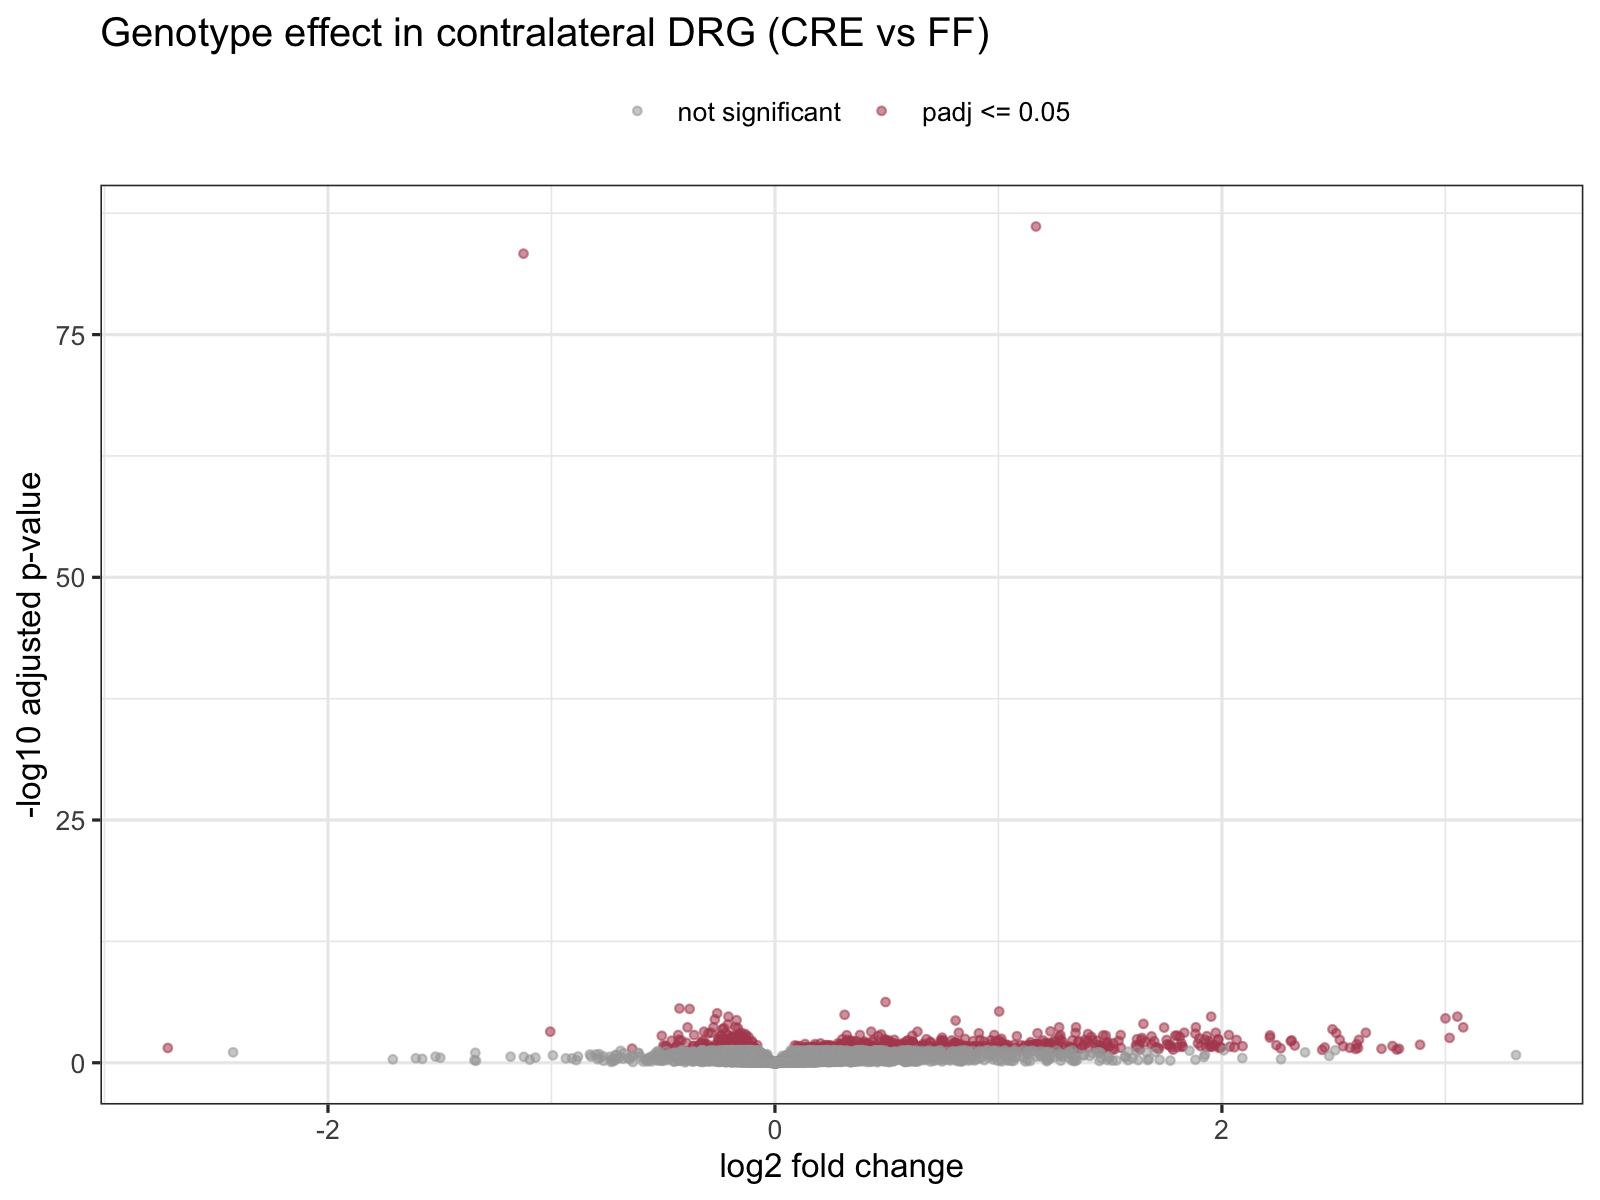
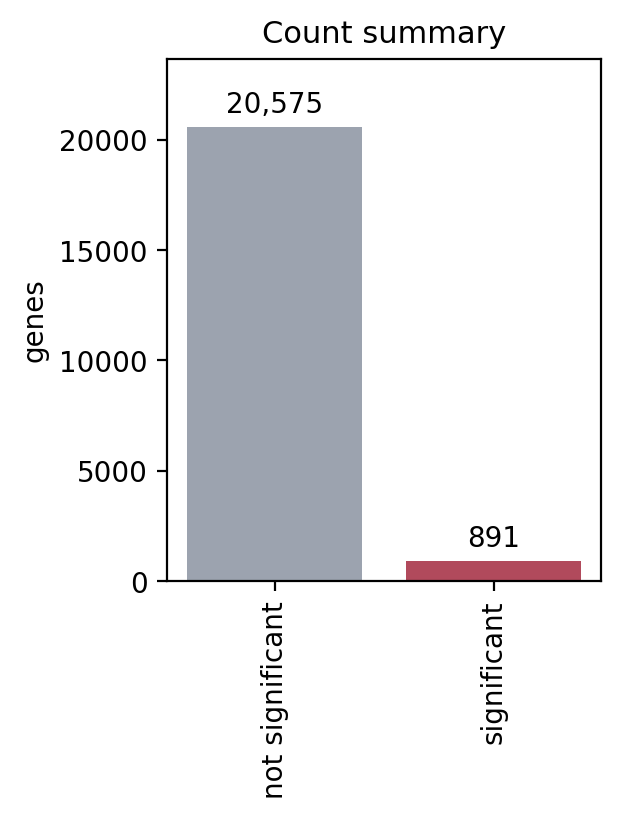

In [18]:
volcano = Path(row['volcano_png'])
if volcano.exists():
    n_sig = int(row['n_significant'])
    n_not = int(row['n_tested'] - row['n_significant'])

    fig, ax = plt.subplots(figsize=(3.2, 4.2))
    ax.bar(['not significant', 'significant'], [n_not, n_sig], color=['#9ca3af', '#b14a5c'])
    ax.set_title('Count summary', fontsize=11)
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('genes')
    ymax = max(n_not, n_sig)
    ax.set_ylim(0, ymax * 1.15)
    for idx, val in enumerate([n_not, n_sig]):
        ax.text(idx, val + ymax * 0.02, f'{val:,}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
    plt.close(fig)
    bar_b64 = base64.b64encode(buf.getvalue()).decode('utf-8')
    volcano_b64 = base64.b64encode(volcano.read_bytes()).decode('utf-8')

    html = f"""
    <div style='display:flex; align-items:flex-start; gap:18px;'>
      <div style='flex: 0 0 auto;'>
        <img src='data:image/png;base64,{volcano_b64}' style='max-width:800px; height:auto; display:block;' />
      </div>
      <div style='flex: 0 0 auto;'>
        <img src='data:image/png;base64,{bar_b64}' style='max-width:260px; height:auto; display:block;' />
      </div>
    </div>
    """
    display(HTML(html))
else:
    print(f'Plot not found: {volcano}')


**What we did:** Displayed the volcano plot for `geno_in_contra`.

**How we did it:** Loaded the volcano plot produced by the DE pipeline for the contralateral genotype contrast.

**What the output means:** This plot shows whether the genotype effect in contralateral DRG is broad and strong or narrower and more modest.

**Interpretation:** In this volcano plot, 891 genes are significant and 20,575 are not. That makes the result clearly real, but still secondary to the two side-specific contrasts. **What this means for the next step:** This plot supports keeping `geno_in_contra` as the strongest secondary contrast in the notebook.


## Shared notebook comparison panels


### `ipsi_vs_contra_in_ff` volcano preview


In [ ]:
display(Image(filename=str(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'ipsi_vs_contra_in_ff_volcano.png'), width=900))


**What we did:** Displayed the `ipsi_vs_contra_in_ff` volcano preview used in the shared team walkthrough.

**How we did it:** Loaded the saved volcano plot directly from the `family_drg_novaseqx/tables/` output bundle.

**What the output means:** This is one of the two dominant side-specific contrasts and one of the quickest visuals for showing the size of the FF signal.

**Interpretation:** This preview belongs in the compact summary because it shows one of the two main paper contrasts immediately. **What this means for the next step:** Use this as one of the first quick-look visuals when summarizing the DE package.


### `ipsi_vs_contra_in_ff` heatmap preview


In [ ]:
display(Image(filename=str(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'ipsi_vs_contra_in_ff_heatmap.png'), width=900))


**What we did:** Displayed the `ipsi_vs_contra_in_ff` heatmap preview used in the shared team walkthrough.

**How we did it:** Loaded the saved heatmap for the FF side-specific contrast from the family tables bundle.

**What the output means:** This heatmap gives a fast view of how the strongest FF contrast separates samples at the gene-pattern level.

**Interpretation:** This preview complements the FF volcano by showing the same dominant contrast as a sample-pattern view. **What this means for the next step:** Keep it paired with the FF volcano when giving a compact summary of the main result.


### `geno_in_contra` volcano preview


In [ ]:
display(Image(filename=str(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'geno_in_contra_volcano.png'), width=900))


**What we did:** Displayed the `geno_in_contra` volcano preview used in the shared team walkthrough.

**How we did it:** Loaded the saved genotype-support volcano directly from the family tables bundle.

**What the output means:** This is the strongest secondary contrast in the package and the most useful compact support panel.

**Interpretation:** This preview shows why `geno_in_contra` is worth keeping as supporting evidence without letting it compete with the side-specific main results. **What this means for the next step:** Use it when a compact notebook summary needs one genotype-support panel.


### `interaction` volcano preview


In [ ]:
display(Image(filename=str(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'interaction_volcano.png'), width=900))


**What we did:** Displayed the `interaction` volcano preview used in the shared team walkthrough.

**How we did it:** Loaded the saved interaction volcano directly from the family tables bundle.

**What the output means:** This is the smallest contrast in the package and is shown here mainly to complete the compact comparison set.

**Interpretation:** The interaction preview stays in the notebook as context, but it should remain minor compared with the two side-specific contrasts and `geno_in_contra`. **What this means for the next step:** Treat this as a small supporting panel only.


### Top genes preview — `ipsi_vs_contra_in_ff`


In [ ]:
display(pd.read_csv(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'ipsi_vs_contra_in_ff_top_genes.tsv', sep='	').head(20))


**What we did:** Displayed the top-gene preview for `ipsi_vs_contra_in_ff`.

**How we did it:** Loaded the saved `ipsi_vs_contra_in_ff_top_genes.tsv` table and previewed the first 20 rows.

**What the output means:** This is the quickest named-gene table for the FF main contrast.

**Interpretation:** This preview is one of the first places to pull named genes when discussing the FF side-specific signal in Draft 1. **What this means for the next step:** Use it as a direct source for gene examples tied to the FF main result.


### Top genes preview — `ipsi_vs_contra_in_cre`


In [ ]:
display(pd.read_csv(OUT_DIR / 'family_drg_novaseqx' / 'tables' / 'ipsi_vs_contra_in_cre_top_genes.tsv', sep='	').head(20))


**What we did:** Displayed the top-gene preview for `ipsi_vs_contra_in_cre`.

**How we did it:** Loaded the saved `ipsi_vs_contra_in_cre_top_genes.tsv` table and previewed the first 20 rows.

**What the output means:** This is the matching named-gene table for the CRE main contrast.

**Interpretation:** This preview lines up with the second main side-specific contrast and should be used beside the FF table when naming genes from the main paper story. **What this means for the next step:** Use it as the CRE counterpart to the FF top-gene table in Draft 1.


## Main takeaways

- The `SRP618841` DE run completed for one balanced DRG family on `NovaSeq X`.
- The strongest visible structure is by side (`ipsi` vs `contra`), which is why the PCA should be interpreted first.
- The two main paper contrasts are `ipsi_vs_contra_in_ff` and `ipsi_vs_contra_in_cre`.
- `geno_in_contra` is the strongest secondary contrast, while `geno_in_ipsi` and `interaction` are much smaller.
- The shared output tree on `sequoia` is:
  - `/home/zebrafish/mouse/SRP618841_parallel/differential_expression_all20`
